In [1]:
import os
import numpy as np
import torch
from IPython.display import display
import clip
from PIL import Image
from tqdm import tqdm
import pandas as pd
from PIL import Image

In [4]:
device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f"Using device: {device}")
batch_size = 32

Using device: mps


In [5]:
def make_path(images_dir, image_id):
    return os.path.normpath(os.path.join(images_dir, image_id + ".jpg"))

def load_model(model_name, device):
    model, preprocess = clip.load(model_name, device=device)
    model.eval()
    return model, preprocess

def encode_images(image_paths, model, preprocess, batch_size, device):
    embeddings = []

    with torch.no_grad():
        for i in tqdm(range(0, len(image_paths), batch_size), desc="Encoding Images"):
            batch_paths = image_paths[i:i + batch_size]

            images = torch.stack([
                preprocess(Image.open(p).convert("RGB"))
                for p in batch_paths
            ]).to(device)

            emb = model.encode_image(images)
            emb = emb / emb.norm(dim=-1, keepdim=True)

            embeddings.append(emb.cpu().numpy())

    embeddings = np.vstack(embeddings).astype("float32")

    embeddings = embeddings / np.linalg.norm(
        embeddings, axis=1, keepdims=True
    )

    return embeddings

def encode_texts(texts, model, device, batch_size=32):
    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]

            tokens = clip.tokenize(batch).to(device)

            emb = model.encode_text(tokens)
            emb = emb / emb.norm(dim=-1, keepdim=True)

            all_embeddings.append(emb.cpu().numpy())

    return np.vstack(all_embeddings).astype("float32")

def retrieve_candidates(query, model, device, image_embeddings, records, top_k=10):

    query_emb = encode_texts([query], model, device)[0]

    query_emb = query_emb / np.linalg.norm(query_emb)

    scores = image_embeddings @ query_emb

    indices = np.argsort(-scores)[:top_k]

    candidates = []
    for idx in indices:
        idx = int(idx)

        candidates.append({
            "idx": idx,
            "image_path": records[idx]["image_path"],
            "title": records[idx]["title"],
            "clip_score": float(scores[idx]),
            "image_emb": image_embeddings[idx],
            "source": "retrieval"
        })

    return candidates

def precision_at_k(candidates, relevant_set, k=10):
    top_k = candidates[:k]

    hits = 0
    for c in top_k:
        if c["idx"] in relevant_set:
            hits += 1

    return hits / k

def evaluate_clip_retrieval(
    queries,
    model,
    device,
    image_embeddings,
    ground_truth,
    k_values=[1, 5, 10]
):
    results = {f"Recall@{k}": [] for k in k_values}

    for query in queries:
        try:
            query_emb = encode_texts([query], model, device)[0]
            query_emb = query_emb / np.linalg.norm(query_emb)

            scores = image_embeddings @ query_emb
            ranked_indices = np.argsort(-scores)

            gt = set(ground_truth.get(query, []))
            if len(gt) == 0:
                continue

            for k in k_values:
                top_k = ranked_indices[:k]
                hit = any(idx in gt for idx in top_k)
                results[f"Recall@{k}"].append(int(hit))

        except Exception as e:
            print(f"Skipping query: {query}", e)

    final = {
        metric: np.mean(vals) if len(vals) > 0 else 0
        for metric, vals in results.items()
    }

    return final

def build_id_to_index(image_paths):
    return {
        path: idx
        for idx, path in enumerate(image_paths)
    }

def build_ground_truth(dataset, images_dir, id_to_index):
    ground_truth = {}
    article_titles = []

    for article_id, group in dataset.groupby(level=0):

        query = group["article_title"].iloc[0]
        article_titles.append(query)

        relevant_indices = []

        for _, row in group.iterrows():
            img_path = make_path(images_dir, row["image_id"])

            if img_path in id_to_index:
                relevant_indices.append(id_to_index[img_path])

        ground_truth[query] = list(set(relevant_indices))

    return article_titles, ground_truth

def build_relevance_dict(ground_truth):
    return {
        q: {idx: 1 for idx in indices}
        for q, indices in ground_truth.items()
    }

def show_top_k_images(records,indices,k=10):
    for i in indices[:k]:
        candidate = records[i]
        img = Image.open(candidate['image_path'])
        display(img)

In [ ]:
model_name = 'ViT-B/32'
model, preprocess = load_model(model_name, device)
dataset_dir = '../dataset/newsimages_train_26_v1.1'
images_dir = f'{dataset_dir}/news_images'
dataset = pd.read_csv(f"{dataset_dir}/news_articles.csv")
dataset.set_index('article_id', inplace=True)

records = [
    {
        "image_path": make_path(images_dir, row['image_id']),
        "title": row['article_title']
    }
    for _, row in dataset.iterrows()
]

image_paths = [r["image_path"] for r in records]
model_path = f"../artifacts/{model_name.replace('/','_').lower()}_image_embeddings.npy"
# image_embeddings = encode_images(image_paths, model, preprocess, batch_size, device)
# np.save(model_path, image_embeddings)

Encoding Images: 100%|██████████| 266/266 [04:02<00:00,  1.10it/s]


In [7]:
image_embeddings = np.load(model_path)
query = 'Overdose deaths involving cocaine mixed with psychostimulants rising: CDC'
candidates = retrieve_candidates(query, model, device, image_embeddings, records, 300)
candidates_indices = [candidate['idx'] for candidate in candidates]


In [8]:
id_to_index = build_id_to_index(image_paths)

article_titles, ground_truth = build_ground_truth(
    dataset,
    images_dir,
    id_to_index
)

ground_truth_relevance = build_relevance_dict(ground_truth)
metrics = evaluate_clip_retrieval(
    article_titles,
    model,
    device,
    image_embeddings,
    ground_truth
)

print(metrics)

{'Recall@1': np.float64(0.22423529411764706), 'Recall@5': np.float64(0.44435294117647056), 'Recall@10': np.float64(0.5370588235294118)}


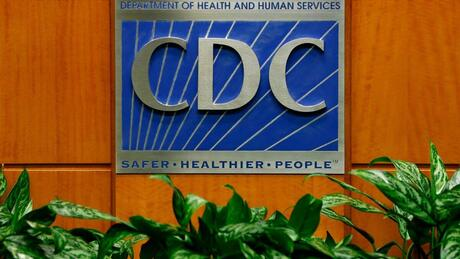

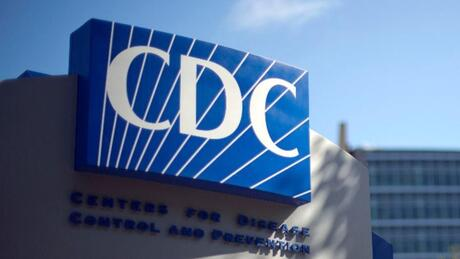

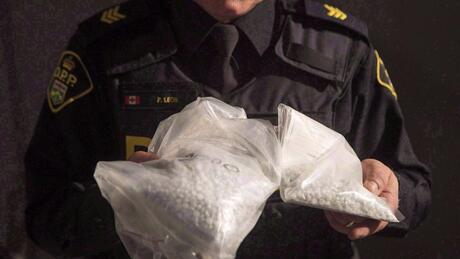

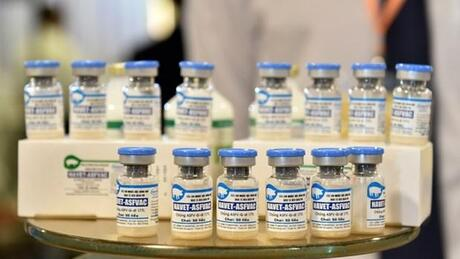

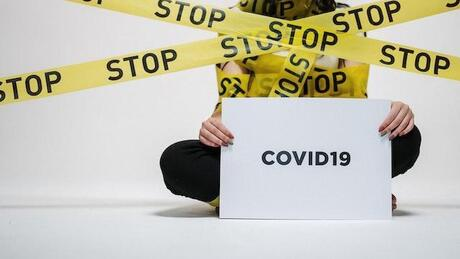

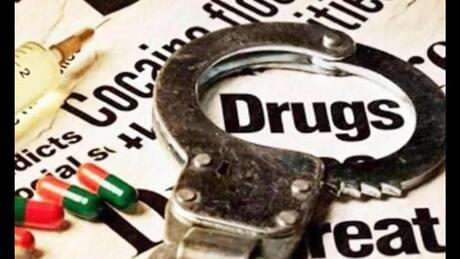

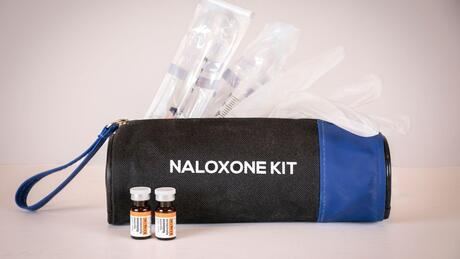

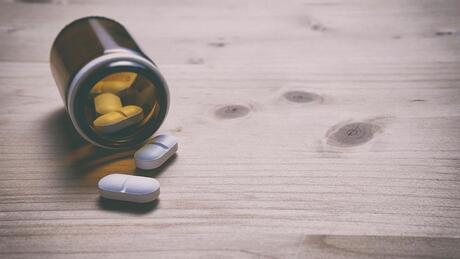

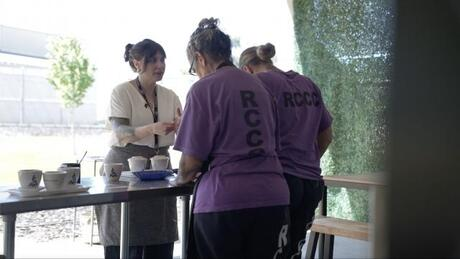

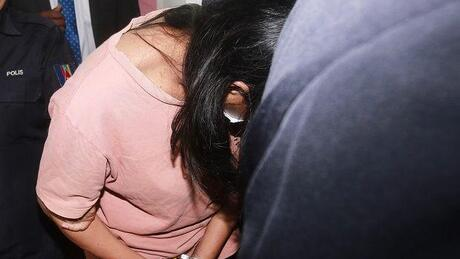

In [9]:
show_top_k_images(records,candidates_indices,10)